In [1]:
import opensim as osim
import numpy as np
import matplotlib.pyplot as plt

In [2]:
model = osim.Model("pendulum.osim")

[info] Loaded model model from file pendulum.osim


In [3]:
reporter = osim.StatesTrajectoryReporter()
reporter.setName("reporter")
reporter.set_report_time_interval(0.001)
model.addComponent(reporter)

In [4]:
starting_time = 0.0
stopping_time = 5.0

state = model.initSystem()
state.setTime(starting_time)

manager = osim.Manager(model, state)
state = manager.integrate(stopping_time)

In [5]:
state_trajectory = reporter.getStates()

times = []
positions = []

for state in state_trajectory:
    times.append(state.getTime())
    positions.append(model.getStateVariableValue(state, "/jointset/pendulum_head_to_pendulum_base/rz/value"))

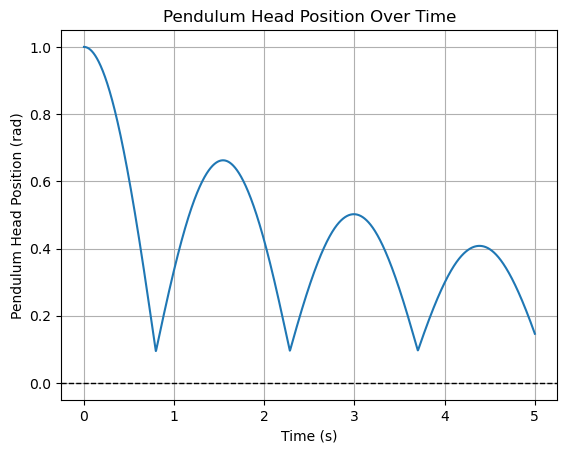

In [6]:
# plot position of the pendulum head
plt.plot(times, positions)
plt.xlabel("Time (s)")
plt.ylabel("Pendulum Head Position (rad)")
plt.title("Pendulum Head Position Over Time")
plt.axhline(0, color='black', lw=1, ls='--')
plt.grid()
plt.savefig("test.png")


-------------------------

In [ ]:
import math

: 

In [ ]:
model = osim.Model()
model.setName('model')

: 

In [ ]:
# Create a pendulum model.
# ------------------------
# In the default pose, the system is a mass hanging 1 meter down from a hinge.
body = osim.Body('body', 1.0, osim.Vec3(0), osim.Inertia(1))
model.addComponent(body)

joint = osim.PinJoint('joint',
        model.getGround(), osim.Vec3(0), osim.Vec3(0), 
        body, osim.Vec3(0, 1.0, 0), osim.Vec3(0))
joint.updCoordinate().setName('q')
model.addComponent(joint)

: 

In [ ]:
# This reporter will collect states throughout the simulation at intervals of
# 0.05 seconds.
reporter = osim.StatesTrajectoryReporter()
reporter.setName('reporter')
reporter.set_report_time_interval(0.05)
model.addComponent(reporter)

: 

In [ ]:
# Simulate.
# ---------
state = model.initSystem()

# The initial position is that the pendulum is rotated 45 degrees
# counter-clockwise from its default pose.
model.setStateVariableValue(state, 'joint/q/value', 0.25 * math.pi)

manager = osim.Manager(model, state)
manager.integrate(1.0)

: 

In [ ]:
# Analyze the simulation.
# -----------------------
# Retrieve the StatesTrajectory from the reporter.
statesTraj = reporter.getStates()

for itime in range(statesTraj.getSize()):
    state = statesTraj[itime]
    time = state.getTime()
    q = model.getStateVariableValue(state, 'joint/q/value')

    # Calculating joint reactions requires realizing to Acceleration.
    model.realizeAcceleration(state)
    # This returns a SpatialVec, which is two Vec3's ([0]: moment, [1]: force).
    reaction = joint.calcReactionOnParentExpressedInGround(state)
    force = reaction.get(1)
    force_mag = math.sqrt(force[0]**2 + force[1]**2 + force[2]**2)
    print('time: %f s.  q: %f rad.  reaction force magnitude: %f N.' % (
        time, q, force_mag))

    # The reaction could also be accessed as an output:
    # abstractOutput = joint.getOutput('reaction_on_parent')
    # output = osim.OutputSpatialVec.safeDownCast(abstractOutput)
    # outputValue = output.getValue(s)

: 

In [ ]:
# Alternately, we could load a StatesTrajectory from a TimeSeriesTable file
# using StatesTrajectory.createFromStatesTable().
statesTable = manager.getStatesTable()
statesTraj2 = osim.StatesTrajectory.createFromStatesTable(model, statesTable)

for itime in range(statesTraj2.getSize()):
    state = statesTraj2[itime]
    time = state.getTime()
    u = model.getStateVariableValue(state, 'joint/q/speed')
    print('time: %f s.  u: %f rad/s.' % (time, u))

: 

: 